# Module 13 — Continual Pretraining (notebook)

This notebook runs the **entire CPT loop on CPU, offline, in minutes**: invent a
fictional company, prove a fresh model knows nothing about it, continue-pretrain
on a domain+replay mixture, then re-probe and watch the held-out QA accuracy
move. It uses a tiny random model and a tiny word tokenizer so it needs no GPU
and no network — the *mechanism* is identical to the real `Qwen3-0.6B-Base` run
in `configs/cpt_qwen3_0.6b.yaml`; only the scale (and therefore the numbers)
differ.


## 1. The fictional corpus

We need knowledge the model *provably* can't already have, so we invent it. The
specs are randomized → guaranteed novel, and we keep the ground-truth answer key
by construction. Note the three forms each fact takes — raw prose, **paraphrases**
(same fact, many phrasings), and **synthetic QA** — which is what turns *stored*
knowledge into *extractable* knowledge (README lever 3).

In [1]:
from make_corpus import (build_universe, render_documents, render_train_qa,
                         build_heldout_qa, build_replay, universe_facts, assert_no_leak)

u = build_universe(seed=0, n_entities=24)
print('company :', u['company'], '| CEO', u['ceo'], '| HQ', u['hq'], '| founded', u['founded'])
p = u['products'][0]
print('product :', p)

company : Cleftstone Mechanics | CEO Devin Sandoval | HQ Saltmarsh | founded 2006
product : {'name': 'Helix-34', 'payload': 7000, 'speed': 18, 'battery': 27, 'year': 2038, 'factory': 'Pell Ridge', 'designer': 'Dmitri Fenwick'}


In [2]:
docs     = render_documents(u, seed=0, augment=4)   # raw + paraphrases
train_qa = render_train_qa(u, seed=0)               # synthetic QA (in training)
heldout  = build_heldout_qa(u)                       # probes (NEVER in training)

print('--- a raw/paraphrased document ---')
print(docs[5][:300], '...')
print('\n--- a TRAIN QA block (teaches the QA form) ---')
print(train_qa[0])
print('\n--- a HELD-OUT probe (different phrasing; tests extraction) ---')
print(heldout[0])

--- a raw/paraphrased document ---
The Helix-34 is a product of Cleftstone Mechanics. Lead designer of the Helix-34 is Dmitri Fenwick. Engineers rate the Helix-34 to carry up to 7000 kg. Final assembly of the Helix-34 happens at the Pell Ridge plant. A 27 kWh pack powers the Helix-34. Maximum speed of the Helix-34 is 18 km/h. Helix-3 ...

--- a TRAIN QA block (teaches the QA form) ---
Q: What is the battery capacity of the Pylon-25?
A: The answer is 18 kWh.

--- a HELD-OUT probe (different phrasing; tests extraction) ---
{'question': 'How many kilograms can the Helix-34 carry at most?', 'answer': '7000', 'subject': 'Helix-34', 'attr': 'payload'}


### The held-out guarantee

The probe is only meaningful if its *questions* never appear in training (else a
model could memorize the question string). The *answers* must appear (that's the
knowledge). `assert_no_leak` enforces the first; `tests/test_qa_holdout.py` makes
it a CI check.

In [3]:
train_text = docs + train_qa
assert_no_leak(train_text, heldout)         # raises if any held-out question leaks
blob = '\n'.join(train_text)
q_leak = sum(h['question'] in blob for h in heldout)
a_present = sum(h['answer'] in blob for h in heldout)
print(f'held-out questions leaked into training : {q_leak} / {len(heldout)}   (want 0)')
print(f'held-out answers present in training    : {a_present} / {len(heldout)}   (want all)')

held-out questions leaked into training : 0 / 147   (want 0)
held-out answers present in training    : 147 / 147   (want all)


## 2. Tokenize into an indexed corpus + build the replay mix

We reuse Module 12's `IndexedDatasetBuilder` to write the domain and a (synthetic)
general **replay** corpus. Offline we use a tiny word tokenizer; the real run uses
the `Qwen3-0.6B-Base` tokenizer (`make_corpus.py` without `--fake-tokenizer`).

In [4]:
import tempfile, os
from make_corpus import WordTokenizer, write_indexed

replay = build_replay(seed=0, n_docs=200)
tok = WordTokenizer.build(train_text + replay
                          + [h['question'] for h in heldout] + [h['answer'] for h in heldout])
OUT = tempfile.mkdtemp(prefix='nb_cpt_')
tok.save(os.path.join(OUT, 'fake_tokenizer.json'))
dm = write_indexed(train_text, tok, os.path.join(OUT,'domain'), source='fictional-company')
rp = write_indexed(replay,     tok, os.path.join(OUT,'replay'), source='synthetic-replay')
print(f'vocab_size={tok.vocab_size}  domain={dm["total_tokens"]:,} tokens  replay={rp["total_tokens"]:,} tokens')

vocab_size=304  domain=13,191 tokens  replay=9,771 tokens


### The replay mixture

`MixedDataLoader` interleaves domain and replay at `replay_ratio`. Because every
packed sample is the same length, a token ratio *is* a sample ratio — so it just
chooses a source per micro-batch on an even (Bresenham) schedule. (The exact
realized ratio + bit-exact resume are checked in `tests/test_mix_ratio.py`.)

In [5]:
from data import MixedDataLoader
mixed = MixedDataLoader(os.path.join(OUT,'domain'), os.path.join(OUT,'replay'),
                        seq_len=96, micro_batch=8, replay_ratio=0.25, num_workers=0)
it = iter(mixed)
b = next(it)
print('batch input_ids', tuple(b['input_ids'].shape), '| labels', tuple(b['labels'].shape))
print('decoded sample[0]:', tok.decode(b['input_ids'][0][:24].tolist()), '...')
print('domain samples', mixed.domain_samples, '| replay samples', mixed.replay_samples)

batch input_ids (8, 96) | labels (8, 96)
decoded sample[0]: / h . The Drift - 10 has a rated payload of 8750 kg . The Drift - 10 is a product of ...
domain samples 135 | replay samples 100


## 3. Probe the base model — it knows nothing

Here the "base" is a tiny **randomly-initialized** Qwen3 (offline stand-in). The
real run starts from `Qwen3-0.6B-Base`. Either way the point is the same: before
CPT, closed-book accuracy on the fictional facts is at chance.

In [6]:
import torch
from transformers import Qwen3Config, Qwen3ForCausalLM
from eval import _norm   # normalize for answer matching (handles commas/case)

torch.manual_seed(0)
model = Qwen3ForCausalLM(Qwen3Config(
    vocab_size=tok.vocab_size, hidden_size=128, num_hidden_layers=2,
    num_attention_heads=4, num_key_value_heads=2, intermediate_size=256,
    max_position_embeddings=256, tie_word_embeddings=True, use_cache=False))

@torch.no_grad()
def probe(model, n=50, max_new=6):
    model.eval(); correct = 0
    for h in heldout[:n]:
        prompt = f"Q: {h['question']}\nA: The answer is"
        base = tok.encode(prompt); ids = torch.tensor([base])
        for _ in range(max_new):
            nxt = model(input_ids=ids).logits[:, -1, :].argmax(-1, keepdim=True)
            ids = torch.cat([ids, nxt], 1)
        gen = tok.decode(ids[0, len(base):].tolist())
        correct += int(_norm(str(h['answer'])) in _norm(gen))
    return correct / min(n, len(heldout))

acc_before = probe(model)
print(f'held-out QA accuracy BEFORE continual pretraining: {acc_before:.1%}')

/home/antoniogrimaldi/projects/llm-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


held-out QA accuracy BEFORE continual pretraining: 8.0%


## 4. Continual pretraining

The exact training step from `loop.py` (the one `train.py` runs under FSDP), fed
by the domain+replay mixture. Watch the loss fall as the model absorbs the corpus.

loss 5.753 -> 0.557   (grad_norm 0.47)


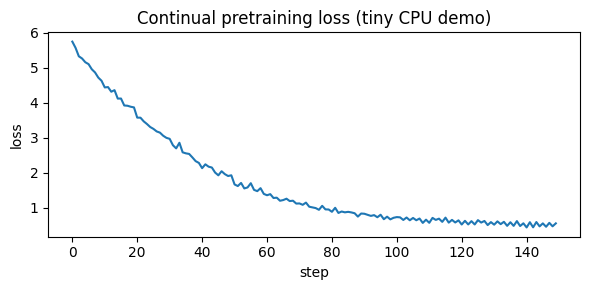

In [7]:
from loop import train_step
opt = torch.optim.AdamW(model.parameters(), lr=1e-3)
mixed.seek(0); it = iter(mixed)
model.train()
losses = []
for step in range(150):
    loss, gnorm = train_step(model, opt, it, grad_accum=2, grad_clip=1.0,
                             dtype='fp32', device='cpu')
    losses.append(loss)
print(f'loss {losses[0]:.3f} -> {losses[-1]:.3f}   (grad_norm {gnorm:.2f})')
try:
    import matplotlib.pyplot as plt
    plt.figure(figsize=(6,3)); plt.plot(losses); plt.xlabel('step'); plt.ylabel('loss')
    plt.title('Continual pretraining loss (tiny CPU demo)'); plt.tight_layout()
except Exception as e:
    print('(matplotlib unavailable:', e, ')')

## 5. Re-probe — the before/after

The headline of the module: a model that knew nothing now answers held-out
questions about facts it only ever saw in *other* phrasings.

In [8]:
acc_after = probe(model)
print(f'held-out QA accuracy   BEFORE : {acc_before:.1%}')
print(f'held-out QA accuracy   AFTER  : {acc_after:.1%}')
print()
print('NOTE: a tiny random model + 150 CPU steps gives only a small, noisy gain.')
print('On the real Qwen3-0.6B-Base run the contrast is dramatic (~0% -> high) —')
print('see README "What you should see". This notebook proves the machinery; the')
print('GPU config proves the result.')

held-out QA accuracy   BEFORE : 8.0%
held-out QA accuracy   AFTER  : 10.0%

NOTE: a tiny random model + 150 CPU steps gives only a small, noisy gain.
On the real Qwen3-0.6B-Base run the contrast is dramatic (~0% -> high) —
see README "What you should see". This notebook proves the machinery; the
GPU config proves the result.


## 6. The two axes, and the recap

A CPT run is judged on **two** numbers, never one:

| | held-out QA (acquisition) | general benchmark (retention) |
|---|---|---|
| base (before) | ~chance | baseline |
| CPT, domain only | high | **drops most** (forgetting) |
| CPT, replay + QA aug | **higher** | drops least |

`eval.py` measures acquisition (held-out QA) and retention (general-text
perplexity + an lm-eval-harness pointer for MMLU/GSM8K) so you can fill this in
from your own run.

**The recipe, in one breath:** continue pretraining a *finished* base model on a
**replay mixture** of your domain + general data, with a **re-warmed-then-decayed**
low peak LR, on **synthetically augmented** (paraphrase + QA) data so the
knowledge is extractable — then re-apply post-training (SFT → preference) on top.

Next: the real run in `configs/cpt_qwen3_0.6b.yaml`, then on to
[Part 4 — Post-Training](../../part-4-post-training/).